In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet(r"C:\Users\91891\Downloads\customer-churn-intelligence-system\data\optimized_df.parquet")
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36,Male,UK,Manchester,1.6,15,42.700001,10.3,37.700001,1,...,42.799999,7,3,NaN,23.299999,3,1067.469971,3028,0,Q4
1,45,Female,Canada,Vancouver,2.9,10,24.799999,1.6,70.900002,1,...,0.000000,4,1,NaN,8.800000,<NA>,1289.750000,2317,0,Q4
2,56,Female,USA,New York,2.6,10,38.400002,14.8,41.700001,9,...,41.400002,2,5,85.900002,31.000000,3,2340.919922,2674,0,Q1
3,35,Male,Japan,Tokyo,3.5,6,21.900000,6.9,74.400002,0,...,16.000000,8,2,14.300000,11.200000,2,1995.430054,2418,1,Q1
4,56,Male,Germany,Berlin,1.9,24,46.400002,13.9,36.200001,5,...,35.500000,4,6,68.800003,42.900002,5,3003.570068,2657,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,33,Male,France,Nice,4.5,6,NaN,6.9,67.099998,2,...,7.100000,8,3,3.200000,12.900000,5,917.830017,1298,1,Q4
39996,18,Female,France,Lyon,4.8,8,21.000000,8.4,69.500000,3,...,17.400000,6,5,15.400000,14.600000,2,813.109985,3565,1,Q2
39997,38,Female,USA,Los Angeles,10.0,10,35.799999,8.8,51.200001,3,...,9.200000,5,1,20.700001,25.200001,1,2365.979980,3499,0,Q2
39998,37,Male,USA,Chicago,1.4,21,32.400002,9.6,32.500000,2,...,17.600000,5,3,38.599998,12.100000,4,1293.599976,3154,0,Q3


In [5]:
corr = df.corr(numeric_only=True)

<Axes: >

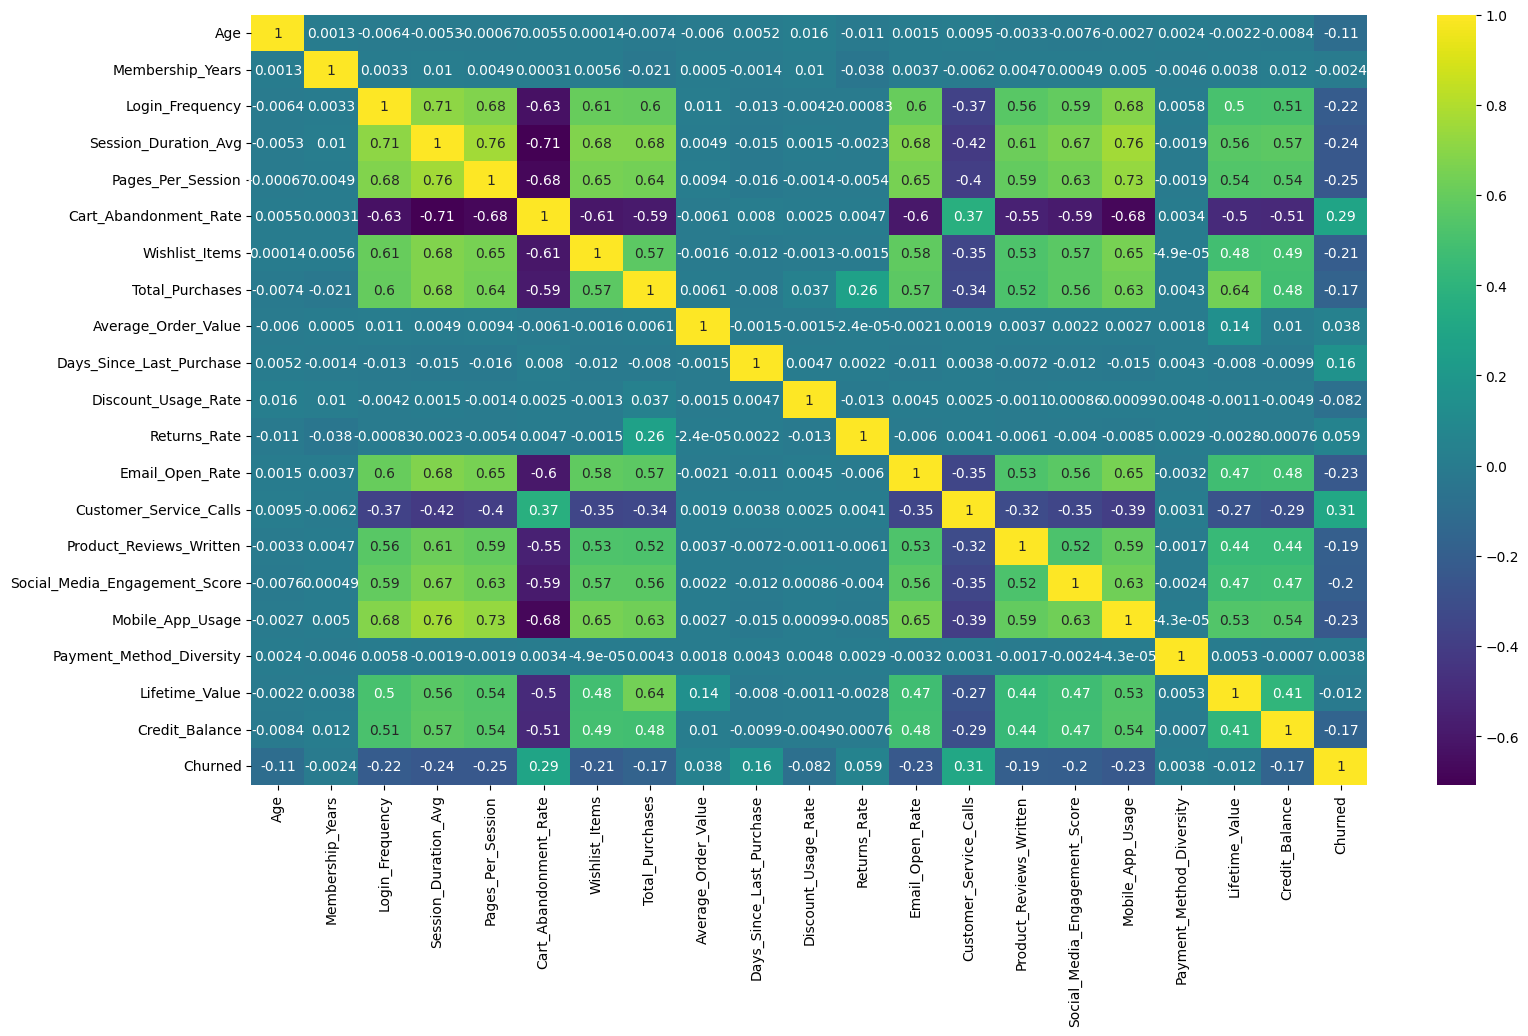

In [15]:
plt.figure(figsize=(18,10))
sns.heatmap(corr,annot=True,cmap="viridis")

### Insights
* Age, Membership_Years, Average_Order_Value, Days_Since_Last_purchase, Discount_Usage_Rate, Returns_Rate, Payment_Method_Diversity are not correlated that much with any of the numerical feature.
* And I can see groups forming.
* A) strong engagement cluster.
* These are highly positively correlated:
* Login_Frequency
* Session_Duration_Avg
* Pages_Per_Session
* Mobile_App_Usage
* Social_Media_Engagement_Score
* Product_Reviews_Written
* Wishlist_Items
* Total_Purchases
* this tells:
##### Highly engaged customers tend to:

1. log in more
2. spend more time
3. browse more pages
4. use app more
5. engage socially
6. review products
7. purchase more

* This is a VERY strong behavioral pattern.

##### Cart_Abandonment opposite cluster, as it has strong negative correlation with
* Login_Frequency
* Session_Duration
* Pages_Per_Session
* Purchases
* App usage
* Customers who abandon carts frequently tend to show lower engagement and weaker purchasing behavior.

##### Churn relationships
* Strongest Positive Correlations with Churn
* Customer_Service_Calls -> +0.31
* VERY important.
* Possible meaning:
* frustrated users
* unresolved issues
* poor experience
* This is a realistic churn indicator.
* Cart_Abandonment_Rate -> +0.29
* Strong churn signal.
* Meaning:
* declining purchase intent
* friction in buying process
* Very useful feature for model.
* Days_Since_Last_Purchase -> +0.16
* Makes business sense.
* Inactive customers churn more.

In [16]:
# Some engagement features are moderately highly correlated with each other, indicating the presence of multicollinearity among customer activity features. This suggests that multiple features may be capturing similar engagement behavior patterns.
# However, these features still provide meaningful business insights individually, such as login activity, browsing behavior, app usage, and customer interaction patterns.
# Strong negative correlations are observed between churn and engagement-related features such as Login_Frequency, Session_Duration_Avg, Mobile_App_Usage, and Total_Purchases. This indicates that active and engaged customers are less likely to churn.
# Features related to engagement and customer activity appear to be stronger churn indicators compared to demographic or transactional features.
# Overall, customer engagement, platform activity, and purchasing behavior appear to play a major role in customer retention and are likely to contribute significantly during model building.